# Практическая работа 4. RNN

IMDB и keras RNN.


!!!!Для корректной работы кода в этом документе, следует выполнить задания из документа “IMDB и keras”!!!!

## Рекуррентные сети

Главной характеристикой всех нейронных сетей, с которыми мы познакомились к данному моменту, таких как полносвязные и сверточные нейронные сети, является отсутствие памяти. Каждый вход обрабатывается ими независимо, без сохранения состояния между ними. Чтобы с помощью таких сетей обработать последовательность или временной ряд данных, необходимо передать в сеть всю последовательность целиком, преобразовав ее в единый пакет. Именно так мы поступили в предыдущем примере: мы преобразовали все отзывы из IMDB в один большой вектор и обработали его целиком. Такие сети называют сетями прямого распространения (feedforward networks).

С другой стороны, читая предложение, мы осмысливаем его слово за словом, быстро перескакивая глазами с одного на другое и запоминая предыдущие; это позволяет нам постепенно вникать в смысл, передаваемый предложением. Биологический интеллект воспринимает информацию последовательно, сохраняя внутреннюю модель обрабатываемого, основываясь на предыдущей информации и постоянно дополняя эту модель по мере поступления новой информации.

Рекуррентная нейронная сеть (Recurrent Neural Network, RNN) использует тот же принцип, хотя и в чрезвычайно упрощенном виде: она обрабатывает последовательность, перебирая ее элементы и сохраняя состояние, полученное при обработке предыдущих элементов. Фактически RNN — это разновидность нейронной сети, имеющей внутренний цикл. Сеть RNN сбрасывает состояние между обработкой двух разных, независимых последовательностей (таких, как два разных отзыва из IMDB), поэтому одна последовательность все еще интерпретируется как единый блок данных: единственный входной пакет. Однако теперь блок данных обрабатывается не за один шаг; сеть выполняет внутренний цикл, перебирая последовательность элементов.

<div align="center">
  <img src="rnn_loop.png" alt="Рекуррентная сеть с циклом" width="520"/>
  <br/>
  <em>Рекуррентная сеть с циклом</em>
</div>


Чтобы пояснить понятия «цикл» и «состояние», реализуем средствами Numpy простую сеть RNN с прямой передачей. Она будет принимать на входе последовательность векторов в виде двумерного тензора с формой (временные_интервалы, входные_признаки), перебирать временные интервалы и, учитывая текущее состояние и входные признаки (с формой (входные_признаки,)) в момент t, конструировать выходной результат, соответствующий моменту t. Этот результат затем будет сохраняться во внутреннем состоянии как подготовка к следующей итерации. Для первого временного интервала предыдущий выходной результат не определен; в этот момент сеть не имеет текущего состояния. Поэтому текущее состояние первоначально инициализируется вектором с нулевыми значениями элементов, который называют начальным состоянием сети.

Чтобы сделать эти понятия абсолютно однозначными, напишем упрощенную реализацию сети RNN на основе Numpy.


In [1]:
from __future__ import annotations

import os
import random
from pathlib import Path

PRACTICE_DIR = Path.cwd()

CACHE_DIR = PRACTICE_DIR / ".cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(CACHE_DIR / "matplotlib")
os.environ["IPYTHONDIR"] = str(CACHE_DIR / "ipython")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

DATA_DIR = PRACTICE_DIR / ".data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
os.environ["KERAS_HOME"] = str(DATA_DIR / "keras_home")

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.datasets import imdb
from tensorflow.keras.layers import (
    Bidirectional,
    Dense,
    Dropout,
    Embedding,
    GRU,
    Input,
    LSTM,
    SimpleRNN,
)
from tensorflow.keras.preprocessing.sequence import pad_sequences

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)
np.set_printoptions(edgeitems=5, linewidth=120)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    tf.config.set_visible_devices([], "GPU")


In [2]:
timesteps = 100 #Число временных интервалов во входной последовательности
input_features = 32 #Размерность пространства входных признаков
output_features = 64 #Размерность пространства выходных признаков

inputs = np.random.random((timesteps, input_features)) #Входные данные: случайный шум для простоты примера
state_t = np.zeros((output_features,)) #Начальное состояние: вектор с нулевыми значениями элементов

W = np.random.random((output_features, input_features)) #Создание матриц со случайными весами
U = np.random.random((output_features, output_features)) #Создание матриц со случайными весами
b = np.random.random((output_features,)) #Создание матриц со случайными весами

successive_outputs = []
for input_t in inputs: #input_t — вектор с формой (входные_признаки,)
    output_t = np.tanh(np.dot(W, input_t) + np.dot(U, state_t) + b) #Объединение входных данных с текущим состоянием (выходными данными на предыдущем шаге)
    successive_outputs.append(output_t) #Сохранение выходных данных в список
    state_t = output_t #Обновление текущего состояния сети как подготовка к обработке следующего временного интервала

final_output_sequence = np.stack(successive_outputs, axis=0) #Окончательный результат — двумерный тензор с формой (временные_интервалы, выходные_признаки)
final_output_sequence.shape


(100, 64)

Довольно просто: как можно заметить, RNN — это цикл for, который повторно использует величины, вычисленные в предыдущей итерации, и не более того. Конечно, вы могли бы сконструировать множество разных сетей RNN, соответствующих этому определению, и этот пример — одна из простейших реализаций RNN. Рекуррентные сети характеризуются функцией, реализующей один шаг, такой как следующая, использованная в данном примере:

`output_t = np.tanh(np.dot(W, input_t) + np.dot(U, state_t) + b)`

<div align="center">
  <img src="rnn_unrolled.png" alt="Простая рекуррентную сеть, развернутая по времени" width="640"/>
  <br/>
  <em>Простая рекуррентную сеть, развернутая по времени</em>
</div>


ПРИМЕЧАНИЕ

В этом примере конечный результат имеет вид двумерного тензора с формой (временные_интервалы, выходные_признаки), где каждый временной интервал — это результат цикла в момент времени t. Каждому временному интервалу t в выходном тензоре соответствует информация о временных интервалах от 0 до t во входной последовательности — обо всем прошлом. Поэтому во многих случаях нет необходимости иметь всю последовательность результатов; достаточно получить последний результат (значение output_t по окончании цикла), так как он уже содержит информацию обо всей последовательности.

## Рекуррентный слой в Keras

Процессу, который мы только что реализовали с применением Numpy, соответствует фактический слой в Keras — слой SimpleRNN:


In [3]:
SimpleRNN


keras.src.layers.rnn.simple_rnn.SimpleRNN

С одним незначительным отличием: SimpleRNN обрабатывает пакеты последовательностей, как и все другие слои в Keras, а не единственную последовательность, как наш предыдущий пример. Это означает, что он принимает входные данные с формой (размер_пакета, временные_интервалы, входные_признаки), а не (временные_интервалы, входные_признаки).

Подобно всем рекуррентным слоям в Keras, SimpleRNN может действовать в двух разных режимах: возвращать полные последовательности результатов для всех временных интервалов (трехмерный тензор с формой (размер_пакета, временные_интервалы, выходные_признаки)) или только последний результат для каждой входной последовательности (двумерный тензор с формой (размер_пакета, входные_признаки)). Выбор режима управляется аргументом return_sequences конструктора. Рассмотрим пример, в котором используется слой SimpleRNN и возвращается результат только для последнего временного интервала:


In [4]:
model = Sequential(
    [
        Input(shape=(None,)),
        Embedding(10000, 32),
        SimpleRNN(32),
    ]
)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 32)       │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,080 (1.23 MB)

 Trainable params: 322,080 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

Следующий пример возвращает полную последовательность состояний:


In [5]:
model = Sequential(
    [
        Input(shape=(None,)),
        Embedding(10000, 32),
        SimpleRNN(32, return_sequences=True),
    ]
)
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, None, 32)       │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, None, 32)       │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,080 (1.23 MB)

 Trainable params: 322,080 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

Иногда полезно наложить друг на друга несколько рекуррентных слоев, чтобы увеличить репрезентативность сети. В таких ситуациях все промежуточные слои должны возвращать полные последовательности результатов:


In [6]:
model = Sequential(
    [
        Input(shape=(None,)),
        Embedding(10000, 32),
        SimpleRNN(32, return_sequences=True),
        SimpleRNN(32, return_sequences=True),
        SimpleRNN(32, return_sequences=True),
        SimpleRNN(32), #Последний слой возвращает только последний результат
    ]
)
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, None, 32)       │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, None, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, None, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, None, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,320 (1.25 MB)

 Trainable params: 328,320 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

Теперь попробуем применить такую же модель для решения задачи классификации отзывов к фильмам из набора данных IMDB. Сначала подготовим данные.


In [7]:
max_features = 10000
maxlen = 500
batch_size = 32

print("Loading data...")
(input_train, y_train), (input_test, y_test) = imdb.load_data(num_words=max_features)
print(len(input_train), "train sequences")
print(len(input_test), "test sequences")

print("Pad sequences (samples x time)")
input_train = pad_sequences(input_train, maxlen=maxlen)
input_test = pad_sequences(input_test, maxlen=maxlen)
print("input_train shape:", input_train.shape)
print("input_test shape:", input_test.shape)


Loading data...
25000 train sequences
25000 test sequences
Pad sequences (samples x time)
input_train shape: (25000, 500)
input_test shape: (25000, 500)


Обучим простую рекуррентную сеть, состоящую из слоев Embedding и SimpleRNN.


In [8]:
model = Sequential(
    [
        Input(shape=(maxlen,)),
        Embedding(max_features, 32),
        SimpleRNN(32),
        Dense(1, activation="sigmoid"),
    ]
)
model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,113 (1.23 MB)

 Trainable params: 322,113 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    input_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)


Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.6041 - loss: 0.6542 - val_accuracy: 0.7690 - val_loss: 0.5254
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.8073 - loss: 0.4365 - val_accuracy: 0.7594 - val_loss: 0.4900
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.8694 - loss: 0.3219 - val_accuracy: 0.8002 - val_loss: 0.5177
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9090 - loss: 0.2406 - val_accuracy: 0.8052 - val_loss: 0.4355
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9415 - loss: 0.1641 - val_accuracy: 0.7360 - val_loss: 0.5941
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9645 - loss: 0.1064 - val_accuracy: 0.7754 - val_loss: 0.5683
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9755 - loss: 0.0769 - val_accuracy: 0.8356 - val_loss: 0.4912
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9866 - loss: 0.0472 - val_accu

Теперь выведем графики изменения величины потерь и точности модели на этапах обучения и проверки.


In [10]:
def plot_training_history(history, title_prefix: str) -> None:
    """Строит графики точности и потерь по объекту History из Keras."""
    history_dict = history.history
    acc_key = "accuracy" if "accuracy" in history_dict else "acc"
    val_acc_key = "val_accuracy" if "val_accuracy" in history_dict else "val_acc"

    acc = history_dict[acc_key]
    val_acc = history_dict[val_acc_key]
    loss = history_dict["loss"]
    val_loss = history_dict["val_loss"]
    epochs = range(1, len(acc) + 1)

    plt.figure()
    plt.plot(epochs, acc, "bo", label="Training acc")
    plt.plot(epochs, val_acc, "b", label="Validation acc")
    plt.title(f"{title_prefix}: training and validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.figure()
    plt.plot(epochs, loss, "bo", label="Training loss")
    plt.plot(epochs, val_loss, "b", label="Validation loss")
    plt.title(f"{title_prefix}: training and validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


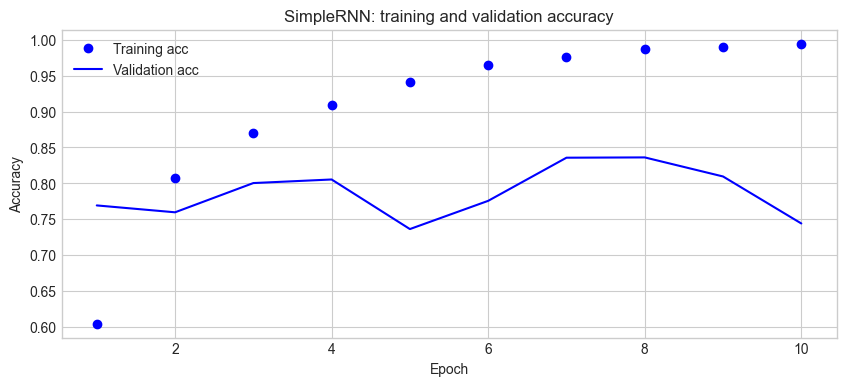

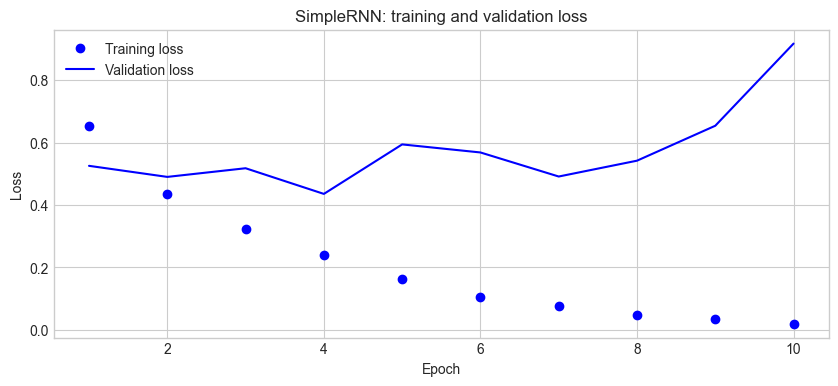

In [11]:
plot_training_history(history, "SimpleRNN")


<p align="center">
  <em>Потери на этапах обучения и проверки для модели анализа IMDB со слоем SimpleRNN</em><br/>
  <em>Точность на этапах обучения и проверки для модели анализа IMDB со слоем SimpleRNN</em>
</p>

К сожалению, эта маленькая рекуррентная сеть показала на этапе проверки точность лишь 85 %. Отчасти проблема объясняется тем, что анализу подвергаются только 500 первых слов в каждом отзыве, а не вся последовательность, следовательно, сеть RNN получает на входе меньше информации, чем модель, с которой мы ее сравниваем. Другая причина в том, что слой SimpleRNN плохо подходит для обработки длинных последовательностей, таких как текст.

Другие типы рекуррентных слоев позволяют добиться более высоких результатов. Рассмотрим несколько таких более продвинутых слоев.

## Слои LSTM и GRU

имеются также слои LSTM и GRU. В практических решениях они используются чаще, потому что SimpleRNN слишком прост для реальных задач. SimpleRNN страдает одной существенной проблемой: теоретически в каждый момент времени t он должен хранить информацию о входных данных за многочисленные предыдущие интервалы времени, но на практике такие протяженные зависимости не поддаются обучению. Это связано с проблемой затухания градиента, напоминающего эффект, который наблюдается в нерекуррентных сетях (сетях прямого распространения) с большим количеством слоев: по мере увеличения количества слоев сеть в конечном итоге становится необучаемой. Теоретическое обоснование этого эффекта было дано Хохрейтером (Hochreiter), Шмидхубером (Schmidhuber) и Бенгио (Bengio) в начале 1990-х (см. Yoshua Bengio, Patrice Simard, and Paolo Frasconi, «Learning Long-Term Dependencies with Gradient Descent Is Difficult», IEEE Transactions on Neural Networks 5, no. 2 (1994)). Слои LSTM и GRU создавались специально для решения этой проблемы.

Рассмотрим слой LSTM. Лежащий в его основе алгоритм долгой краткосрочной памяти (Long Short-Term Memory, LSTM) был разработан Хохрейтером и Шмидхубером в 1997 (см. Sepp Hochreiter and Jürgen Schmidhuber, «Long Short-Term Memory», Neural Computation 9, no. 8 (1997)); он стал кульминацией их исследований проблемы затухания градиента.

Этот слой является вариантом слоя SimpleRNN, уже знакомого вам; он добавляет поддержку переноса информации через многие интервалы времени. Вообразите конвейерную ленту, движущуюся параллельно обрабатываемой последовательности. Информация из последовательности может в любой момент перекладываться на конвейерную ленту, переноситься к более поздним интервалам времени и сниматься с ленты, если она необходима. В этом заключается суть работы слоя LSTM: он сохраняет информацию для последующего использования, тем самым предотвращая постепенное затухание старых сигналов во время обработки.

Чтобы разобраться более детально, начнем с ячейки SimpleRNN. Так как у нас имеется большое количество весовых матриц, выходные матрицы W и U в ячейке мы обозначим индексом o (Wo и Uo) — от англ. output (выходной, на выходе).

<div align="center">
  <img src="lstm_carry_flow.png" alt="Переход от SimpleRNN к LSTM: добавление несущего потока" width="640"/>
  <br/>
  <em>Переход от SimpleRNN к LSTM: добавление несущего потока</em>
</div>


А теперь о деталях способа вычисления следующего значения в несущем потоке данных: он основывается на трех разных преобразованиях, все три имеют форму ячейки SimpleRNN:

`y = activation(dot(state_t, U) + dot(input_t, W) + b)`

Однако эти преобразования имеют свои весовые матрицы, которые мы обозначим индексами i, f и k. Вот что мы имеем (это может показаться необоснованным, но наберитесь терпения, я все объясню позже).

Реализация архитектуры LSTM в псевдокоде:

```
output_t = activation(dot(state_t, Uo) + dot(input_t, Wo) + dot(C_t, Vo) + bo)
i_t = activation(dot(state_t, Ui) + dot(input_t, Wi) + bi)
f_t = activation(dot(state_t, Uf) + dot(input_t, Wf) + bf)
k_t = activation(dot(state_t, Uk) + dot(input_t, Wk) + bk)
```

Получим новое переносимое состояние (далее обозначается как c_t), объединив i_t, f_t и k_t.

`c_t+1 = i_t * k_t + c_t * f_t`

<div align="center">
  <img src="lstm_anatomy.png" alt="Анатомия LSTM" width="720"/>
  <br/>
  <em>Анатомия LSTM</em>
</div>


Добавим это в общую картину, как показано на рис. 6. Вот и все. Совсем несложно, просто немного замысловато.

Если хотите удариться в философию, подумайте о том, что делает каждая из этих операций. Например, можно сказать, что умножение c_t на f_t — это способ преднамеренного забывания ненужной информацию в несущем потоке данных. А умножение i_t на k_t представляет собой информацию о настоящем, добавляя новую информацию в несущий поток. Но в конечном счете эти интерпретации не имеют большого значения, потому что фактическое действие операций определяется содержимым параметризующих их весов, а веса вычисляются непрерывно и заново в каждом цикле обучения, что делает невозможным приписать какую-то конкретную цель той или иной операции. Спецификация ячейки RNN (как только что было описано) определяет ваше пространство гипотез — пространство, в котором в процессе обучения вы будете искать оптимальные настройки модели, однако она не определяет, что именно делает ячейка, — это зависит от весов в ячейке. Одна и та же ячейка с разными весами может действовать совершенно иначе. Поэтому набор операций, образующих ячейку RNN, лучше рассматривать как набор ограничений в вашем поиске, а не как дизайн в инженерном смысле.

С точки зрения исследователя, выбор таких ограничений — особенностей реализации ячеек RNN — лучше переложить на алгоритмы оптимизации (такие, как обобщенные алгоритмы обучения с подкреплением) и избавить людей-инженеров от него. В будущем именно так мы и будем строить сети. Подводя итог, можно сказать, что от вас не требуется понимания особенности архитектуры ячейки LSTM; это не ваша задача как человека. Просто помните назначение ячейки LSTM: позволить прошлой информации повторно внедриться в процесс обучения и оказать сопротивление проблеме затухания градиента.

Cоздадим модель со слоем LSTM и обучим ее на данных IMDB. Новая сеть похожа на предыдущую, со слоем SimpleRNN. Мы указали только размерность результата слоя LSTM, оставив другие аргументы (а их довольно много) со значениями по умолчанию. Значения по умолчанию подобраны в Keras очень хорошо и пригодны для большинства ситуаций, что избавляет нас от необходимости тратить время на настройку параметров вручную.


In [12]:
model = Sequential(
    [
        Input(shape=(maxlen,)),
        Embedding(max_features, 32),
        LSTM(32),
        Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    input_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)


Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 110ms/step - accuracy: 0.6694 - loss: 0.5956 - val_accuracy: 0.7180 - val_loss: 0.5461
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - accuracy: 0.8302 - loss: 0.3947 - val_accuracy: 0.8636 - val_loss: 0.3310
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 105ms/step - accuracy: 0.8714 - loss: 0.3255 - val_accuracy: 0.8744 - val_loss: 0.3073
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 105ms/step - accuracy: 0.8841 - loss: 0.2951 - val_accuracy: 0.8582 - val_loss: 0.3633
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 107ms/step - accuracy: 0.8928 - loss: 0.2733 - val_accuracy: 0.8638 - val_loss: 0.3305
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 106ms/step - accuracy: 0.9077 - loss: 0.2435 - val_accuracy: 0.8706 - val_loss: 0.3208
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 107ms/step - accuracy: 0.9126 - loss: 0.2310 - val_accuracy: 0.8760 - val_loss: 0.3344
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - accuracy: 0.9226 - loss: 0

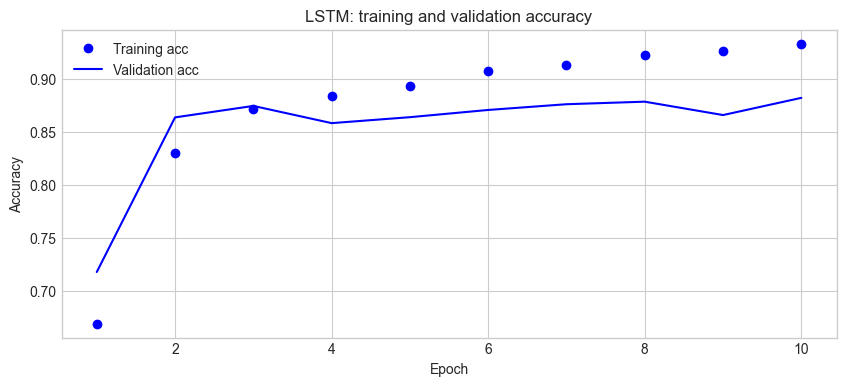

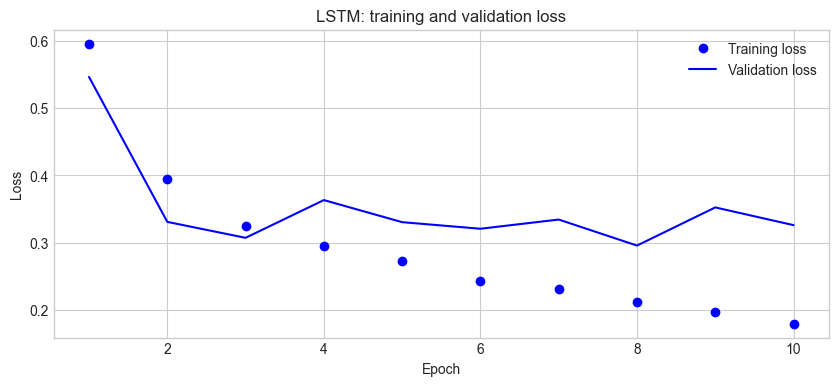

In [14]:
plot_training_history(history, "LSTM")
